# CSEE 4121: Memory-Bound vs. Compute-Bound

In this colab, we'll see firsthand why **batch size** changes everything about GPU performance. Training (large batches) is compute-bound. Inference (batch=1) is memory-bound.

---

Before you start: Make sure you have a GPU runtime.
- Go to **Runtime → Change runtime type → T4 GPU**
- Then run the cell below to confirm.

In [1]:
import torch
import time
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "No GPU found! Go to Runtime -> Change runtime type -> T4 GPU"
gpu_name = torch.cuda.get_device_name(0)
print(f"GPU: {gpu_name}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
GPU Memory: 15.6 GB


## Background

A GPU has two key resources:
1. **Compute** (FLOPS) — how many math operations per second it can do
2. **Memory bandwidth** (TB/s) — how fast it can read data from memory

For the T4 GPU:
- Peak FP16 compute: **65 TFLOPS** (65 trillion operations/sec)
- Memory bandwidth: **300 GB/s**

When you multiply a weight matrix `W` (shape 4096×4096) by an input `X` (shape 4096×batch_size):
- **Compute needed:** 2 × 4096 × 4096 × batch_size FLOPs
- **Data loaded from memory:** The weight matrix W = 4096 × 4096 × 2 bytes (FP16) = 32 MB

At **small batch sizes**, you load 32 MB of weights but do very little compute → **memory-bound** (waiting for data).

At **large batch sizes**, you load the same 32 MB of weights but do tons of compute → **compute-bound** (GPU cores fully busy).

Let's measure this.

## Exercise 1: Time matrix multiplication at different batch sizes

We'll multiply a 4096×4096 weight matrix (simulating one layer of a large model) by input vectors of increasing batch size.

In [ ]:
# Simulate a single linear layer: output = input @ weights
# Weight matrix is 4096 x 4096 (typical hidden dimension for a ~7B model)

M = 4096  # hidden dimension
N = 4096  # hidden dimension

# Create the weight matrix (stays the same regardless of batch size)
W = torch.randn(M, N, dtype=torch.float16, device='cuda')

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
times_ms = []
tflops_list = []

for bs in batch_sizes:
    X = torch.randn(bs, M, dtype=torch.float16, device='cuda')

    # Warmup
    for _ in range(10):
        _ = X @ W
    torch.cuda.synchronize()

    # Timed runs
    num_runs = 100
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(num_runs):
        _ = X @ W
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / num_runs

    # Compute FLOPS: matrix multiply of (bs x M) @ (M x N) = 2 * bs * M * N FLOPs
    flops = 2 * bs * M * N
    tflops = flops / elapsed / 1e12

    times_ms.append(elapsed * 1000)
    tflops_list.append(tflops)

    print(f"Batch size {bs:>5d} | Time: {elapsed*1000:>8.3f} ms | Achieved: {tflops:>6.2f} TFLOPS")

print(f"\nT4 peak FP16: 65 TFLOPS")

Batch size     1 | Time:    0.162 ms | Achieved:   0.21 TFLOPS
Batch size     2 | Time:    0.177 ms | Achieved:   0.38 TFLOPS
Batch size     4 | Time:    0.178 ms | Achieved:   0.75 TFLOPS
Batch size     8 | Time:    0.180 ms | Achieved:   1.49 TFLOPS
Batch size    16 | Time:    0.189 ms | Achieved:   2.84 TFLOPS
Batch size    32 | Time:    0.147 ms | Achieved:   7.29 TFLOPS
Batch size    64 | Time:    0.151 ms | Achieved:  14.18 TFLOPS
Batch size   128 | Time:    0.239 ms | Achieved:  17.97 TFLOPS
Batch size   256 | Time:    0.415 ms | Achieved:  20.72 TFLOPS
Batch size   512 | Time:    0.823 ms | Achieved:  20.88 TFLOPS
Batch size  1024 | Time:    1.447 ms | Achieved:  23.75 TFLOPS
Batch size  2048 | Time:    2.705 ms | Achieved:  25.40 TFLOPS
Batch size  4096 | Time:    5.849 ms | Achieved:  23.50 TFLOPS

T4 peak FP16: 65 TFLOPS


## Exercise 2: Plot throughput vs. batch size

Run the cell below to visualize the results. You should see the classic "roofline" shape.

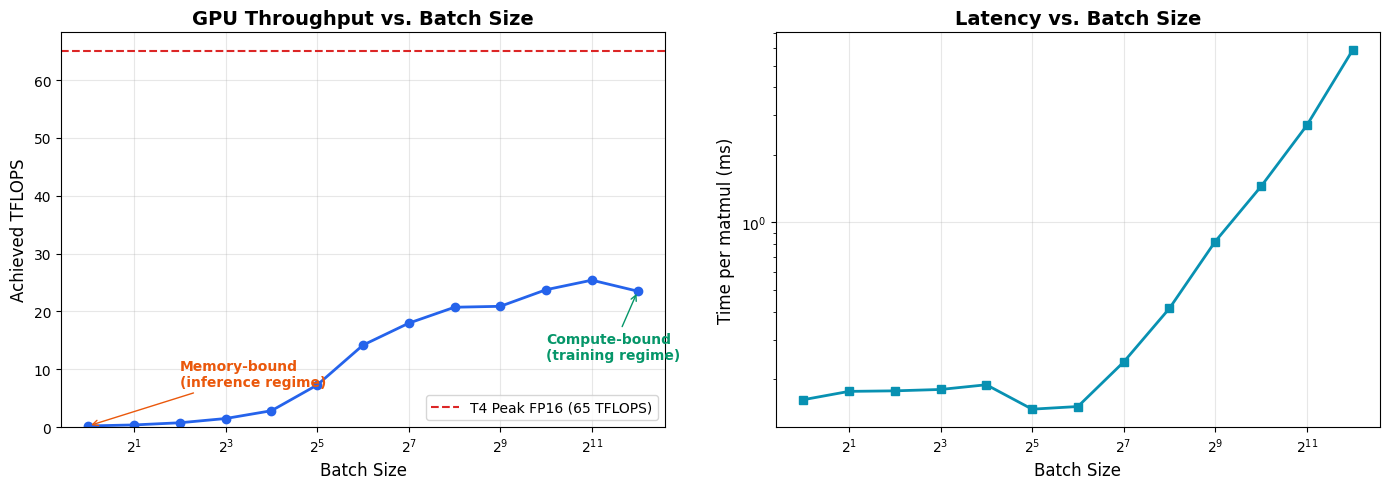

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: TFLOPS vs batch size
ax1.plot(batch_sizes, tflops_list, 'o-', color='#2563EB', linewidth=2, markersize=6)
ax1.axhline(y=65, color='#DC2626', linestyle='--', label='T4 Peak FP16 (65 TFLOPS)')
ax1.set_xscale('log', base=2)
ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Achieved TFLOPS', fontsize=12)
ax1.set_title('GPU Throughput vs. Batch Size', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Add annotations
ax1.annotate('Memory-bound\n(inference regime)',
            xy=(batch_sizes[0], tflops_list[0]),
            xytext=(4, tflops_list[-1]*0.3),
            fontsize=10, color='#EA580C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#EA580C'))

ax1.annotate('Compute-bound\n(training regime)',
            xy=(batch_sizes[-1], tflops_list[-1]),
            xytext=(batch_sizes[-3], tflops_list[-1]*0.5),
            fontsize=10, color='#059669', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#059669'))

# Plot 2: Time per operation vs batch size
ax2.plot(batch_sizes, times_ms, 's-', color='#0891B2', linewidth=2, markersize=6)
ax2.set_xscale('log', base=2)
ax2.set_yscale('log')
ax2.set_xlabel('Batch Size', fontsize=12)
ax2.set_ylabel('Time per matmul (ms)', fontsize=12)
ax2.set_title('Latency vs. Batch Size', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 3: Calculate the arithmetic intensity

**Arithmetic intensity** = FLOPs per byte loaded from memory. It tells you whether an operation is memory-bound or compute-bound.

For our matrix multiply `(batch_size × 4096) @ (4096 × 4096)`:
- FLOPs = 2 × batch_size × 4096 × 4096
- Bytes loaded = weight matrix + input = (4096 × 4096 × 2) + (batch_size × 4096 × 2)

Fill in the code below to compute and plot arithmetic intensity.

In [ ]:
arithmetic_intensities = []

for bs in batch_sizes:
    flops = 2 * bs * M * N
    bytes_loaded = (M * N * 2) + (bs * M * 2)  # weights + input, FP16 = 2 bytes

    # TODO: compute arithmetic intensity (FLOPs / bytes)
    ai = flops / bytes_loaded  # <-- fill this in

    arithmetic_intensities.append(ai)
    print(f"Batch size {bs:>5d} | FLOPs: {flops:>12,} | Bytes: {bytes_loaded:>12,} | Arith. Intensity: {ai:>8.1f} FLOPs/byte")

print(f"\n--- Reference ---")
print(f"T4 compute ceiling: 65 TFLOPS")
print(f"T4 bandwidth ceiling: 300 GB/s")
print(f"Crossover point (ridge point): 65e12 / 300e9 = {65e12/300e9:.0f} FLOPs/byte")
print(f"Below {65e12/300e9:.0f} FLOPs/byte → memory-bound. Above → compute-bound.")

Batch size     1 | FLOPs:   33,554,432 | Bytes:   33,562,624 | Arith. Intensity:      1.0 FLOPs/byte
Batch size     2 | FLOPs:   67,108,864 | Bytes:   33,570,816 | Arith. Intensity:      2.0 FLOPs/byte
Batch size     4 | FLOPs:  134,217,728 | Bytes:   33,587,200 | Arith. Intensity:      4.0 FLOPs/byte
Batch size     8 | FLOPs:  268,435,456 | Bytes:   33,619,968 | Arith. Intensity:      8.0 FLOPs/byte
Batch size    16 | FLOPs:  536,870,912 | Bytes:   33,685,504 | Arith. Intensity:     15.9 FLOPs/byte
Batch size    32 | FLOPs: 1,073,741,824 | Bytes:   33,816,576 | Arith. Intensity:     31.8 FLOPs/byte
Batch size    64 | FLOPs: 2,147,483,648 | Bytes:   34,078,720 | Arith. Intensity:     63.0 FLOPs/byte
Batch size   128 | FLOPs: 4,294,967,296 | Bytes:   34,603,008 | Arith. Intensity:    124.1 FLOPs/byte
Batch size   256 | FLOPs: 8,589,934,592 | Bytes:   35,651,584 | Arith. Intensity:    240.9 FLOPs/byte
Batch size   512 | FLOPs: 17,179,869,184 | Bytes:   37,748,736 | Arith. Intensity:    4

## Exercise 4: The Roofline Model

The roofline model shows the theoretical maximum performance as a function of arithmetic intensity. Run the cell below to see where each batch size lands.

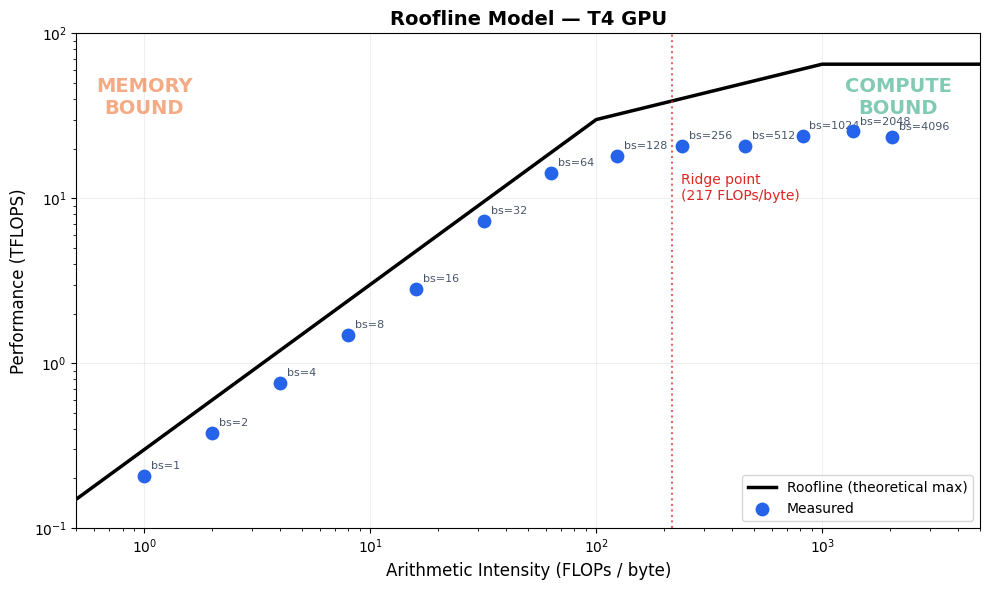

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# T4 specs
peak_tflops = 65
peak_bw_gbs = 300
ridge_point = peak_tflops * 1e12 / (peak_bw_gbs * 1e9)  # FLOPs/byte

# Roofline
ai_range = [0.1, 1, 10, 100, 1000, 10000]
roofline = [min(peak_tflops, ai * peak_bw_gbs / 1e3) for ai in ai_range]

ax.plot(ai_range, roofline, 'k-', linewidth=2.5, label='Roofline (theoretical max)')
ax.scatter(arithmetic_intensities, tflops_list, c='#2563EB', s=80, zorder=5, label='Measured')

# Label each point with batch size
for i, bs in enumerate(batch_sizes):
    ax.annotate(f'bs={bs}', (arithmetic_intensities[i], tflops_list[i]),
               textcoords="offset points", xytext=(5, 5), fontsize=8, color='#475569')

# Mark the ridge point
ax.axvline(x=ridge_point, color='#DC2626', linestyle=':', alpha=0.7)
ax.text(ridge_point * 1.1, peak_tflops * 0.15, f'Ridge point\n({ridge_point:.0f} FLOPs/byte)',
        color='#DC2626', fontsize=10)

# Labels
ax.text(1, peak_tflops * 0.5, 'MEMORY\nBOUND', fontsize=14, color='#EA580C',
        fontweight='bold', alpha=0.5, ha='center')
ax.text(ridge_point * 10, peak_tflops * 0.5, 'COMPUTE\nBOUND', fontsize=14, color='#059669',
        fontweight='bold', alpha=0.5, ha='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Arithmetic Intensity (FLOPs / byte)', fontsize=12)
ax.set_ylabel('Performance (TFLOPS)', fontsize=12)
ax.set_title('Roofline Model — T4 GPU', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_ylim(0.1, 100)
ax.set_xlim(0.5, 5000)

plt.tight_layout()
plt.show()

## Discussion Questions

Look at your plots and answer these:

1. **At batch size 1** (simulating single-user inference), what fraction of the GPU's peak TFLOPS are you achieving? Is this memory-bound or compute-bound?

2. **At batch size 4096** (simulating a training batch), what fraction of peak are you achieving? Is this memory-bound or compute-bound?

3. **Where is the transition point?** At roughly what batch size does the GPU go from memory-bound to compute-bound?

4. **Why does this matter for inference costs?** If you're serving one user at a time (batch=1), you're using maybe 1-5% of the GPU's compute capability. The rest is wasted, waiting for memory. What could you do to improve this? (Hint: think about batching multiple users' requests together.)

5. **Look at the latency plot (right side).** Notice that going from batch=1 to batch=64 barely increases latency, but throughput goes up dramatically. Why? (Hint: at small batches, the time is dominated by memory access, which is the same regardless of batch size.)

6. **Connect this to the lecture:** The DeepSeek V3 / Llama comparison showed that inference is memory-bound. Your experiment just proved this directly. How does quantization (INT4 instead of FP16) help? (Hint: it halves the weight matrix size, so the bytes loaded from memory drops.)

## Bonus: See the effect of quantization on throughput

If we could use INT8 weights (1 byte each instead of 2), we'd load half the data from memory. Let's simulate this by using a smaller matrix and see if throughput improves at small batch sizes.

In [ ]:
# We can't truly do INT8 matmul easily in vanilla PyTorch on T4,
# but we can simulate the effect by comparing two weight matrix sizes.
# A 4096x4096 FP16 matrix = 32 MB
# A 4096x2048 FP16 matrix = 16 MB (same bytes as a 4096x4096 INT8 matrix)

W_full = torch.randn(4096, 4096, dtype=torch.float16, device='cuda')  # 32 MB (simulates FP16 weights)
W_half = torch.randn(4096, 2048, dtype=torch.float16, device='cuda')  # 16 MB (simulates INT8-equivalent bytes)

test_batches = [1, 4, 16, 64, 256, 1024]

print(f"{'Batch':>6} | {'FP16 (32MB)':>14} | {'~INT8 (16MB)':>14} | {'Speedup':>8}")
print("-" * 52)

for bs in test_batches:
    X_full = torch.randn(bs, 4096, dtype=torch.float16, device='cuda')
    X_half = torch.randn(bs, 4096, dtype=torch.float16, device='cuda')

    # Warmup
    for _ in range(10):
        _ = X_full @ W_full
        _ = X_half @ W_half
    torch.cuda.synchronize()

    # Time FP16-sized
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(200):
        _ = X_full @ W_full
    torch.cuda.synchronize()
    time_full = (time.perf_counter() - t0) / 200

    # Time INT8-equivalent-sized
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(200):
        _ = X_half @ W_half
    torch.cuda.synchronize()
    time_half = (time.perf_counter() - t0) / 200

    speedup = time_full / time_half
    print(f"{bs:>6} | {time_full*1000:>11.3f} ms | {time_half*1000:>11.3f} ms | {speedup:>7.2f}x")

print(f"\nAt small batch sizes (memory-bound), halving the weight size should give ~2x speedup.")
print(f"At large batch sizes (compute-bound), the speedup shrinks — you're no longer bottlenecked on memory.")

 Batch |    FP16 (32MB) |   ~INT8 (16MB) |  Speedup
----------------------------------------------------
     1 |       0.151 ms |       0.077 ms |    1.97x
     4 |       0.153 ms |       0.077 ms |    1.99x
    16 |       0.159 ms |       0.081 ms |    1.98x
    64 |       0.138 ms |       0.093 ms |    1.48x
   256 |       0.338 ms |       0.203 ms |    1.67x
  1024 |       1.386 ms |       0.778 ms |    1.78x

At small batch sizes (memory-bound), halving the weight size should give ~2x speedup.
At large batch sizes (compute-bound), the speedup shrinks — you're no longer bottlenecked on memory.


## Summary

What you proved today:

| | Memory-Bound (small batch) | Compute-Bound (large batch) |
|---|---|---|
| **Bottleneck** | Memory bandwidth | GPU compute cores |
| **GPU utilization** | Low (1-10% of peak) | High (50-80% of peak) |
| **Typical workload** | Inference (1 user) | Training (large batch) |
| **Optimization** | Quantize weights, batch users | Use mixed precision, bigger GPU |

This is the fundamental systems insight behind everything we covered in lecture today:
- Why inference is expensive and inefficient per-user
- Why batching multiple users helps so much
- Why quantization speeds up inference (less data to load) but barely helps training (already compute-bound)
- Why the memory hierarchy on your GPU matters